## Load data

In [93]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days

# Choose Ecosystem and Metric
ecosystem = 'LaurentianMapleGrove'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'transfer_entropy'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24
df_all_seasons_combined['Season name'] = df_all_seasons_combined['Season'].map({SPRING: 'Spring', SUMMER: 'Summer', FALL: 'Fall', WINTER: 'Winter'})


## Correlation with distances

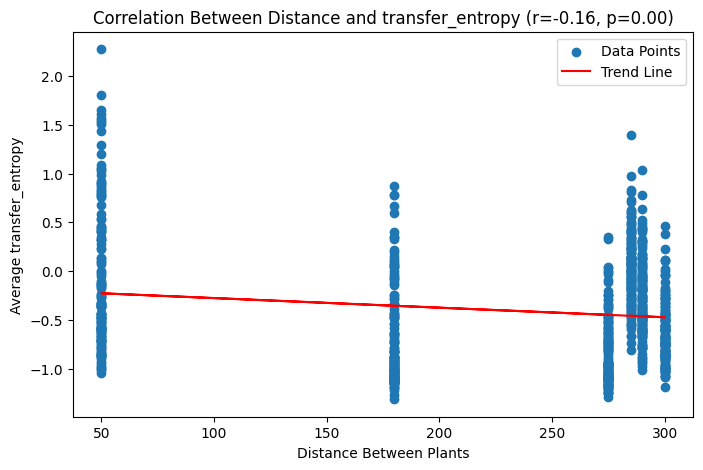

(-0.15554442615959285, 4.70800197822572e-06)

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

SEASON = SUMMER
# Given distance dictionary
plant_distances = {
    (0, 1): 40.0, (0, 2): 99.819, (0, 3): 135.341, (0, 4): 114.927, (0, 5): 168.411,
    (0, 6): 184.897, (0, 7): 80.211, (1, 2): 61.954, (1, 3): 106.234, (1, 4): 136.881,
    (1, 5): 171.512, (1, 6): 174.213, (1, 7): 51.379, (2, 3): 107.564, (2, 4): 165.548,
    (2, 5): 168.839, (2, 6): 149.459, (2, 7): 34.355, (3, 4): 243.108, (3, 5): 269.638,
    (3, 6): 256.786, (3, 7): 131.534, (4, 5): 85.266, (4, 6): 135.399, (4, 7): 131.278,
    (5, 6): 61.243, (5, 7): 138.757, (6, 7): 128.509
}

plant_distances = {
    (3, 6): 50,
    (7, 6): 275,
    (7, 3): 300,
    (7, 1): 180,
    (1, 6): 290,
    (1, 3): 285
}
df_avg = df_all_seasons_combined[df_all_seasons_combined["Season"] == SEASON]

# Convert to DataFrame
df_distances = pd.DataFrame(list(plant_distances.items()), columns=["Plant_Pair", "Distance"])
df_distances[["Plant1", "Plant2"]] = pd.DataFrame(df_distances["Plant_Pair"].tolist(), index=df_distances.index)
df_distances = df_distances.drop(columns=["Plant_Pair"])

# Merge with the previously computed average entropy DataFrame
df_correlation = df_avg.merge(df_distances, on=["Plant1", "Plant2"], how="inner")

# Compute Pearson correlation coefficient
correlation, p_value = stats.pearsonr(df_correlation["Distance"], df_correlation[metric])

# Plot scatter with regression line
plt.figure(figsize=(8, 5))
plt.scatter(df_correlation["Distance"], df_correlation[metric], label="Data Points")
m, b = np.polyfit(df_correlation["Distance"], df_correlation[metric], 1)
plt.plot(df_correlation["Distance"], m * df_correlation["Distance"] + b, color='red', label="Trend Line")

# Labels and title
plt.xlabel("Distance Between Plants")
plt.ylabel(f"Average {metric}")
plt.title(f"Correlation Between Distance and {metric} (r={correlation:.2f}, p={p_value:.2f})")
plt.legend()
plt.show()

# Display the correlation result
correlation, p_value


In [96]:
from scipy.stats import pearsonr
import numpy as np

# Compute observed correlation
obs_corr, _ = pearsonr(df_correlation["Distance"], df_correlation[metric])

# Permutation Test
n_permutations = 1000
perm_corrs = []
for _ in range(n_permutations):
    shuffled_entropy = np.random.permutation(df_correlation[metric])
    perm_corr, _ = pearsonr(df_correlation["Distance"], shuffled_entropy)
    perm_corrs.append(perm_corr)

# Compute p-value (two-tailed)
p_value = np.sum(np.abs(perm_corrs) >= np.abs(obs_corr)) / n_permutations

print(f"Observed Correlation: {obs_corr:.3f}, Permutation p-value: {p_value:.5f}")


Observed Correlation: -0.156, Permutation p-value: 0.00000


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q('transfer_entropy')
No. Observations: 858     Method:             REML                 
No. Groups:       3       Scale:              0.2330               
Min. group size:  143     Log-Likelihood:     -606.3461            
Max. group size:  429     Converged:          Yes                  
Mean group size:  286.0                                            
----------------------------------------------------------------------
             Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
----------------------------------------------------------------------
Intercept    -0.278       0.222    -1.253    0.210    -0.712     0.157
Distance     -0.000       0.000    -0.249    0.803    -0.001     0.001
Group Var     0.124       0.260                                       



<Figure size 800x500 with 0 Axes>

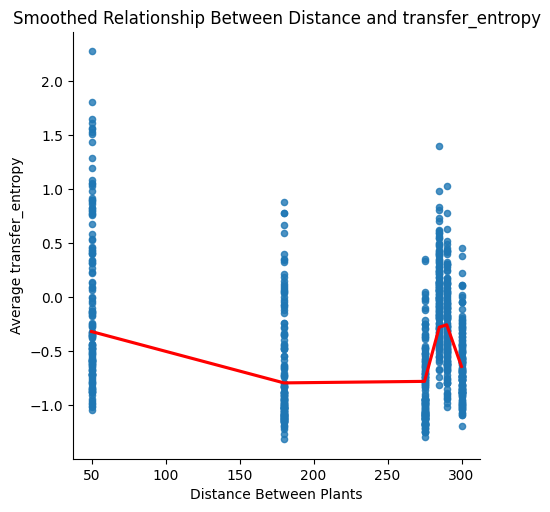

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

SEASON = SUMMER
# Given distance dictionary

df_avg = df_all_seasons_combined[df_all_seasons_combined["Season"] == SEASON]

# Merge distances with entropy
df_correlation = df_avg.merge(df_distances, on=["Plant1", "Plant2"], how="inner")

# Linear Mixed Model (LMM)
model = smf.mixedlm(f"Q('{metric}') ~ Distance", df_correlation, groups=df_correlation["Plant1"])
result = model.fit()

# Print results
print(result.summary())

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.lmplot(x="Distance", y=metric, data=df_correlation, scatter_kws={"s": 20}, lowess=True, line_kws={"color": "red"})
plt.xlabel("Distance Between Plants")
plt.ylabel(f"Average {metric}")
plt.title(f"Smoothed Relationship Between Distance and {metric}")
plt.show()



## LMM for distance on all seasons

In [98]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the seasons for analysis
seasons_list = list(seasons.keys())

# Initialize an empty list to store model results
results_list = []

# Iterate over each season and fit the Linear Mixed Model (LMM)
for season in seasons_list:
    df_avg = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]
    # normalize distance and transfer entropy
    
    df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()

    # Merge distances with entropy
    df_correlation = df_avg.merge(df_distances, on=["Plant1", "Plant2"], how="inner")
    df_correlation["Distance"] = (df_correlation["Distance"] - df_correlation["Distance"].mean()) / df_correlation["Distance"].std()
    # Fit the Linear Mixed Model
    model = smf.mixedlm(f"Q('{metric}') ~ Distance", df_correlation, groups=df_correlation["Plant1"])
    result = model.fit()

    # Extract relevant values
    coef_distance = result.params["Distance"]
    p_value_distance = result.pvalues["Distance"]
    intercept = result.params["Intercept"]
    aic = result.aic

    # Store results in a dictionary
    results_list.append({
        "Season": season,
        "Intercept": intercept,
        "Distance Coefficient": coef_distance,
        "P-value (Distance)": p_value_distance,
        #"AIC": aic
    })

# Convert results to a DataFrame
df_results_summary = pd.DataFrame(results_list)

# Display the results table
print(df_results_summary)


     Season  Intercept  Distance Coefficient  P-value (Distance)
0   Serie 3  -0.660903             -0.629000       1.463143e-129
1  Serie 29   0.061683             -0.013399        8.033226e-01
2  Serie 36   0.291141              0.426774        4.905235e-09
3   Serie 2  -0.021343              0.185931        7.426390e-03


C:\Users\skite\AppData\Local\Temp\ipykernel_28708\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()
C:\Users\skite\AppData\Local\Temp\ipykernel_28708\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()
C:\Users\skite\AppData\Local\Temp\ipykernel_28708\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set o

In [70]:
df_results_summary

,Season,Intercept,Distance Coefficient,P-value (Distance)
0,Serie 6,-0.265427,-0.076919,1.314635e-06
1,Serie 23,-0.089417,-0.163551,7.445264e-15
2,Serie 37,-0.479856,0.426299,3.607463e-100
3,Serie 38,-0.142074,0.042971,8.169178e-03


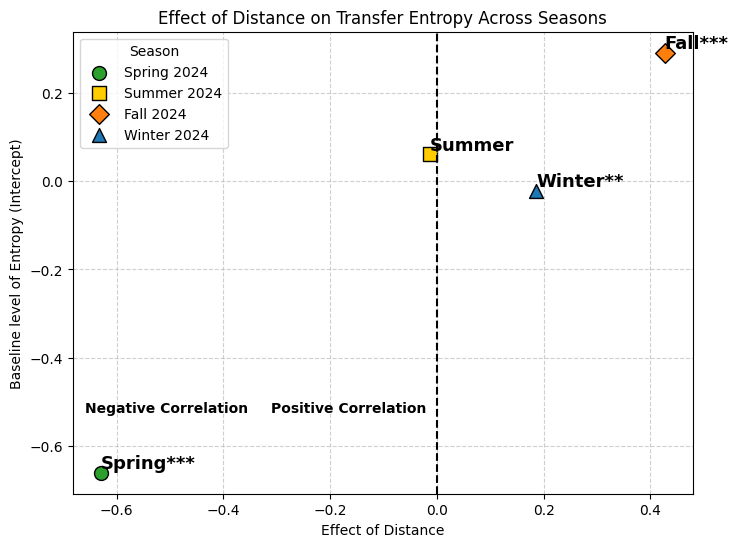

In [99]:
import matplotlib.pyplot as plt
import numpy as np

df_results_summary["Season"] = df_results_summary["Season"].replace(seasons)
# Define season colors and markers
season_mapping = seasons.copy()
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

season_markers = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["o", "s", "D", "^"])}  # Circle, Square, Diamond, Triangle

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot for Intercept vs Distance Coefficient
for i, row in df_results_summary.iterrows():
    ax.scatter(row["Distance Coefficient"], row["Intercept"],
               color=season_colors[row["Season"]],
               marker=season_markers[row["Season"]],
               s=100, label=row["Season"], edgecolors="black")

# Add annotations
for i, row in df_results_summary.iterrows():
    if row["P-value (Distance)"] < 0.001:
        # Annotate extremely significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '***',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    elif row["P-value (Distance)"] < 0.01:
        # Annotate highly significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '**',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    elif row["P-value (Distance)"] < 0.05:
        # Annotate significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '*',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    
    
    else:
        # Annotate non-significant points without asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0],
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    # ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '***',
    #         fontsize=13, ha="left", va="bottom", fontweight="bold")

# Add grid
ax.grid(True, linestyle="--", alpha=0.6)

# Labels and title
ax.set_xlabel("Effect of Distance")
ax.set_ylabel("Baseline level of Entropy (Intercept)")
ax.set_title("Effect of Distance on Transfer Entropy Across Seasons")

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), title="Season", loc="best")
# add black line at 0
ax.axvline(x=0, color='black', linestyle='--')
# write 'positive correlation' and 'negative correlation'
ax.text(0.32, 0.2, 'Positive Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
ax.text(0.02, 0.2, 'Negative Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")

# Show plot
plt.show()


## LMM including season as a variable

In [100]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Normalize Distance and Transfer Entropy across all seasons
df_all_seasons_combined[metric] = (
    df_all_seasons_combined[metric] - df_all_seasons_combined[metric].mean()
) / df_all_seasons_combined[metric].std()

# Merge distances with entropy
df_correlation = df_all_seasons_combined.merge(df_distances, on=["Plant1", "Plant2"], how="inner")

df_correlation["Distance"] = (df_correlation["Distance"] - df_correlation["Distance"].mean()) / df_correlation["Distance"].std()

df_correlation["Season"] = df_correlation["Season"].map(season_mapping)
# Fit a single Linear Mixed Model (LMM)
model = smf.mixedlm(
    f"Q('{metric}') ~ Distance * C(Season)",  # Main effects + Interaction
    df_correlation,
    groups=df_correlation["Plant1"],  # Plants as random intercepts
)
result = model.fit()

# Print results
print(result.summary())


                    Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Q('transfer_entropy')
No. Observations:     3003       Method:                REML                 
No. Groups:           3          Scale:                 0.5981               
Min. group size:      429        Log-Likelihood:        -3508.7857           
Max. group size:      1573       Converged:             Yes                  
Mean group size:      1001.0                                                 
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          0.294    0.099   2.985 0.003  0.101  0.487
C(Season)[T.Spring 2024]          -0.813    0.050 -16.298 0.000 -0.911 -0.715
C(Season)[T.Summer 2024]          -0.743    0.037 -19.877 0.000 -0.816 -0.670
C(Seas

In [101]:
plant_distances

{(3, 6): 50, (7, 6): 275, (7, 3): 300, (7, 1): 180, (1, 6): 290, (1, 3): 285}

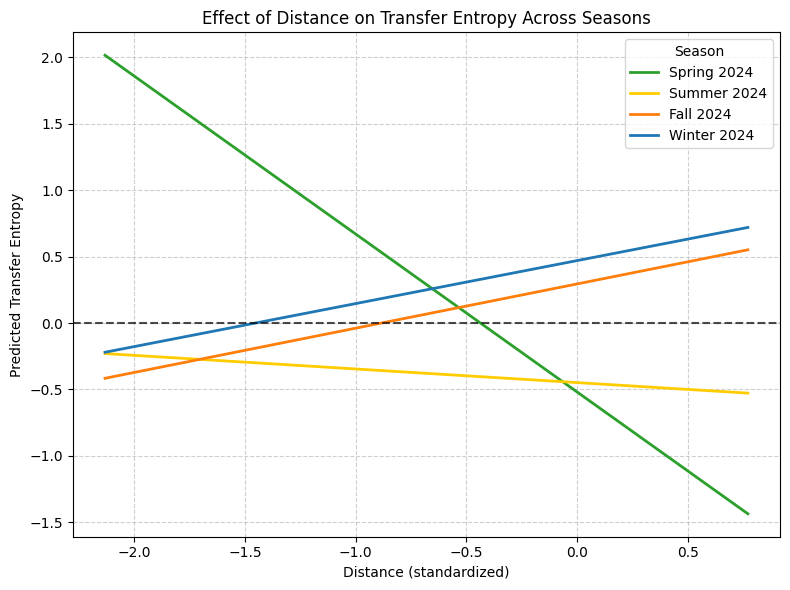

In [102]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare prediction grid ---

# 1) Get the unique seasons and ensure they stay in the original order
season_levels = df_correlation["Season"].dropna().unique()
seasons = pd.Categorical(season_levels, categories=season_levels, ordered=True)

# 2) Create a smooth range of Distance values (standardized)
distance_grid = np.linspace(
    df_correlation["Distance"].min(),
    df_correlation["Distance"].max(),
    100
)

# 3) Build the DataFrame for prediction
pred_df = pd.DataFrame([
    {"Distance": d, "Season": s}
    for d in distance_grid
    for s in seasons
])
pred_df["Season"] = pd.Categorical(pred_df["Season"], categories=season_levels, ordered=True)

# --- Predict ---

pred_df["Predicted_TE"] = result.predict(pred_df)

# --- Plotting ---

# Define colors for each season
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

fig, ax = plt.subplots(figsize=(8, 6))

for season in season_levels:
    mask = pred_df["Season"] == season
    ax.plot(
        pred_df.loc[mask, "Distance"],
        pred_df.loc[mask, "Predicted_TE"],
        label=season,
        color=season_colors.get(season, None),
        linewidth=2
    )

# Add baseline, labels, legend, grid
ax.axhline(0, linestyle="--", color="black", alpha=0.7)
ax.set_xlabel("Distance (standardized)")
ax.set_ylabel("Predicted Transfer Entropy")
ax.set_title("Effect of Distance on Transfer Entropy Across Seasons")
ax.legend(title="Season")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [77]:
model = smf.mixedlm(
    f"Q('{metric}') ~ Distance * C(Season) + C(Plant1)",  
    df_correlation,
    groups=df_correlation["Plant2"],
    re_formula="~ Distance"  
)

result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                MixedLM    Dependent Variable:    Q('transfer_entropy')
No. Observations:     12012      Method:                REML                 
No. Groups:           7          Scale:                 0.7362               
Min. group size:      572        Log-Likelihood:        -15262.0670          
Max. group size:      3432       Converged:             Yes                  
Mean group size:      1716.0                                                 
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          0.204    0.177   1.154 0.249 -0.142  0.550
C(Season)[T.Spring 2024]          -0.258    0.026  -9.961 0.000 -0.308 -0.207
C(Season)[T.Summer 2024]          -0.381    0.028 -13.374 0.000 -0.436 -0.325
C(Season)[T.Winter 2025]          -0.033    0.028  -1.150 0.250 -0.088  0.023
C(Plant1)[T.1]                    -0.206    0.028  -7.309 0.000 -0.262 -0.151
C(Plant1)[T.2]                     0.163    0.029   5.691 0.000  0.107  0.219
C(Plant1)[T.3]                     0.084    0.042   1.996 0.046  0.002  0.166
C(Plant1)[T.4]                     0.106    0.040   2.631 0.009  0.027  0.184
C(Plant1)[T.5]                    -0.048    0.051  -0.951 0.342 -0.148  0.051
C(Plant1)[T.6]                    -0.088    0.055  -1.595 0.111 -0.196  0.020
Distance                           0.371    0.107   3.473 0.001  0.162  0.580
Distance:C(Season)[T.Spring 2024] -0.234    0.027  -8.635 0.000 -0.287 -0.181
Distance:C(Season)[T.Summer 2024] -0.288    0.030  -9.747 0.000 -0.346 -0.230
Distance:C(Season)[T.Winter 2025] -0.025    0.032  -0.800 0.424 -0.087  0.037
Group Var                          0.186    0.141                            
Group x Distance Cov               0.081    0.074                            
Distance Var                       0.061    0.050                            
=============================================================================

"""

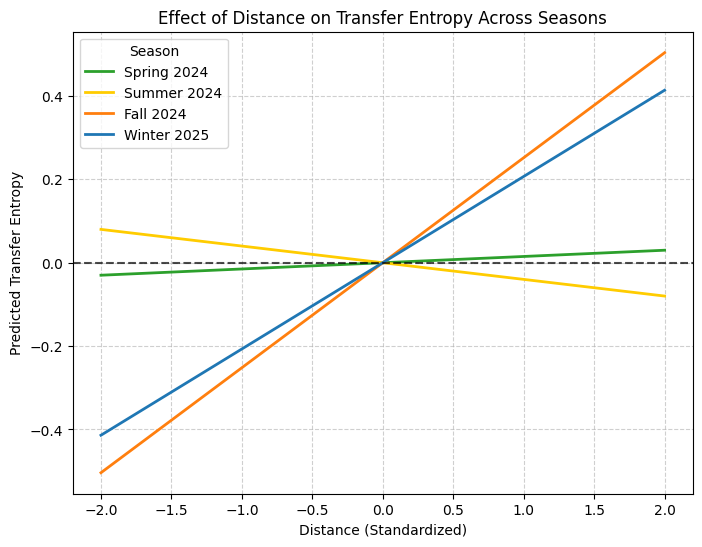

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define season colors
season_colors = {
    "Spring 2024": "#2ca02c",
    "Summer 2024": "#ffcc00",
    "Fall 2024": "#ff7f0e",
    "Winter 2025": "#1f77b4"
}

# Extract slopes for each season
base_slope = 0.252  # Distance main effect
season_slopes = {
    "Spring 2024": base_slope - 0.237,
    "Summer 2024": base_slope - 0.292,
    "Fall 2024": base_slope,  # Reference category
    "Winter 2025": base_slope - 0.045
}

# Generate standardized distance values
distances = np.linspace(-2, 2, 100)

# Plot results
plt.figure(figsize=(8, 6))
for season, slope in season_slopes.items():
    plt.plot(distances, slope * distances, label=season, color=season_colors[season], linewidth=2)

plt.axhline(0, linestyle="--", color="black", alpha=0.7)
plt.xlabel("Distance (Standardized)")
plt.ylabel("Predicted Transfer Entropy")
plt.title("Effect of Distance on Transfer Entropy Across Seasons")
plt.legend(title="Season")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


C:\Users\skite\AppData\Local\Temp\ipykernel_6772\2644188353.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Effect", y="Plant", data=df_plant_effects, palette="coolwarm", edgecolor="black")


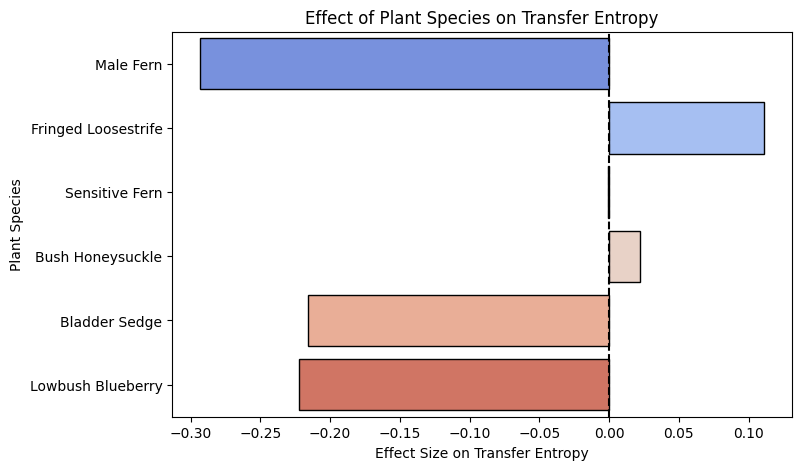

In [ ]:
import seaborn as sns

# Mapping of plant indices to names
plant_names = {
    1: "Male Fern",
    2: "Fringed Loosestrife",
    3: "Sensitive Fern",
    4: "Bush Honeysuckle",
    5: "Bladder Sedge",
    6: "Lowbush Blueberry",
}

# Extract coefficients for plants
plant_effects = {
    "Male Fern": -0.293,
    "Fringed Loosestrife": 0.111,
    "Sensitive Fern": -0.001,
    "Bush Honeysuckle": 0.022,
    "Bladder Sedge": -0.216,
    "Lowbush Blueberry": -0.222,
}

# Convert to DataFrame
df_plant_effects = pd.DataFrame(plant_effects.items(), columns=["Plant", "Effect"])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Effect", y="Plant", data=df_plant_effects, palette="coolwarm", edgecolor="black")

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Effect Size on Transfer Entropy")
plt.ylabel("Plant Species")
plt.title("Effect of Plant Species on Transfer Entropy")
plt.show()
